<a href="https://colab.research.google.com/github/alstjgg/customer_churn_prediction/blob/dev/Data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
**The final objective of this project is to...**
- Visualize customer statuses to get the general idea of the deomgraphic of service users.
- Find significant factors that determine whether the customer is going to churn.
- Determine which customers are likely to churn, and visualize the danger factors of said customer.

**Here, we will check the status of each table.**
- How does the distribution look like? Are there any outliers? Is the data skewed or normal?
- Are there any missing values? If so, how can we fill them?
- Are there any anomalies? In other words, are there values that cannnot exist? If so, how can we fix them?
- Are there any columns that are redundant or has no meaning? Can we delete them altogether?

**Next, we will combine all tables into one dataframe**
- We will find a common unique field in all the tables to use as a combining column.
- We are doing this for EDA.

# Initialize

## Import libraries

In [ ]:
!pip install missingno

In [ ]:
# from utility import *
import numpy as np
import pandas as pd
import os
import missingno as msno
import random

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cycler import cycler
import matplotlib.gridspec as gridspec



## Set visualization

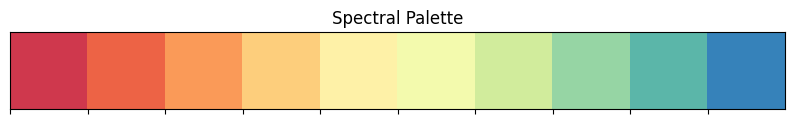

In [ ]:
# set palette
sns.palplot(sns.color_palette("Spectral", 10))
plt.title("Spectral Palette")
plt.show()

palette = sns.color_palette("Spectral", 10)
random.shuffle(palette)
rcParams['axes.prop_cycle'] = cycler('color', palette)

# set grid
sns.set_style("whitegrid", {'axes.grid' : False})

In [ ]:
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

## Load Data

In [ ]:
cd /content/drive/MyDrive/Customer\ Churn\ Prediction

/content/drive/MyDrive/Customer Churn Prediction


In [ ]:
root = os.path.join(os.getcwd(), 'data')

In [ ]:
raw_demographics = pd.read_excel(os.path.join(root, 'Telco_customer_churn_demographics.xlsx'))
raw_location = pd.read_excel(os.path.join(root, 'Telco_customer_churn_location.xlsx'))
raw_population = pd.read_excel(os.path.join(root, 'Telco_customer_churn_population.xlsx'))
raw_services = pd.read_excel(os.path.join(root, 'Telco_customer_churn_services.xlsx'))
raw_status = pd.read_excel(os.path.join(root, 'Telco_customer_churn_status.xlsx'))
raw_churn = pd.read_excel(os.path.join(root, 'Telco_customer_churn.xlsx'))
# CustomerChurn = pd.read_excel(os.path.join(root, 'CustomerChurn.xlsx'))

## Dataset description
The Telco customer churn data contains information about a fictional telco company that provided home phone and Internet services to **7043 customers** in **California** in **Q3**.  
It indicates which customers have left, stayed, or signed up for their service.
Multiple important demographics are included for each customer, as well as a Satisfaction Score, Churn Score, and Customer Lifetime Value (CLTV) index.

### Tables
- demographics
- location
- population
- services
- status
- churn

# Data Overview

## demographics
|Column Name|Description|Type|Value|
|---|---|---|---|
|CustomerID|A unique ID that identifies each customer|string|4 numbers + '-' + 5 letters|
|Count|A value used in reporting/dashboarding to sum up the number of customers in a filtered set|int|1|
|Gender|The customer’s gender|String|'Male', 'Female'|
|Age|The customer’s current age, in years, at the time the fiscal quarter ended|Discrete integer|19, .. , 80|
|Under 30|Indicates if the customer is 30 or younger|String|'Yes', 'No'|
|Senior Citizen|Indicates if the customer is 65 or older|String|'Yes', 'No'|
|Married|Indicates if the customer is married|String|'Yes', 'No'|
|Dependents|Indicates if the customer lives with any dependents (Dependents could be children, parents, grandparents, etc) |String|'Yes', 'No'|
|Number of Dependents|Indicates the number of dependents that live with the customer|Discrete integer|0, 1, ..., 9|


In [ ]:
# @title Overview
display(raw_demographics.sample(3))
display(raw_demographics.info())

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
4349,4884-LEVMQ,1,Male,39,No,No,Yes,No,0
2713,1950-KSVVJ,1,Female,57,No,No,Yes,No,0
4308,9534-NSXEM,1,Male,28,Yes,No,No,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Customer ID           7043 non-null   object
 1   Count                 7043 non-null   int64 
 2   Gender                7043 non-null   object
 3   Age                   7043 non-null   int64 
 4   Under 30              7043 non-null   object
 5   Senior Citizen        7043 non-null   object
 6   Married               7043 non-null   object
 7   Dependents            7043 non-null   object
 8   Number of Dependents  7043 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 495.3+ KB


None

In [ ]:
# @title Missing Values
# display(msno.matrix(raw_demographics))
display(raw_demographics.isna().sum())

# @markdown There are no missing values

,0
Customer ID,0
Count,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0


In [ ]:
# @title Customer ID
ids = raw_demographics[['Customer ID']].copy()
ids['ID_len'] = ids['Customer ID'].str.split('-').apply(lambda x: len(x))
ids['ID_num'] = ids['Customer ID'].str.split('-').apply(lambda x: x[0])
ids['ID_char'] = ids['Customer ID'].str.split('-').apply(lambda x: x[1])

In [ ]:
display(ids.sample(3))

,Customer ID,ID_len,ID_num,ID_char
6703,7018-FPXHH,2,7018,FPXHH
1156,9420-LOJKX,2,9420,LOJKX
1675,8128-YVJRG,2,8128,YVJRG


In [ ]:
display(ids.ID_num.sort_values().reset_index(drop=True))
display(ids.ID_char.sort_values().reset_index(drop=True))

,ID_num
0,0002
1,0003
2,0004
3,0011
4,0013
...,...
7038,9987
7039,9992
7040,9992
7041,9993


,ID_char
0,AAAGJ
1,AACSZ
2,AADLV
3,AADSA
4,AAFQH
...,...
7038,ZZLOH
7039,ZZRBQ
7040,ZZRVX
7041,ZZTFS


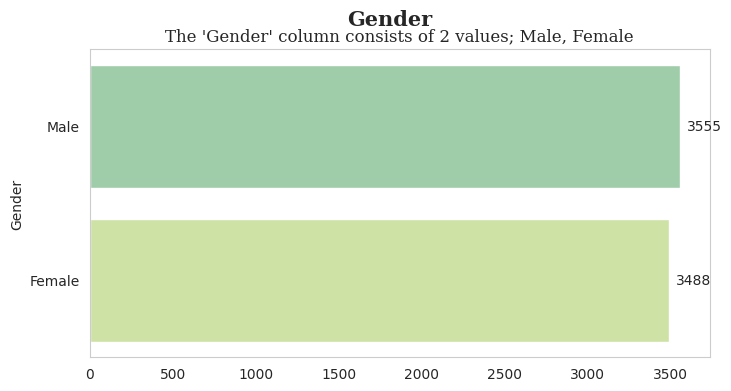

In [ ]:
# @title Gender
gender = raw_demographics['Gender'].value_counts()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=gender.values, y=gender.index, hue=gender.index)
for p in ax.patches:
    ax.annotate(int(p.get_width()),
                (p.get_width(), p.get_y() + p.get_height() / 2),  # position text at the center of each bar
                ha='left', va='center',  # horizontal and vertical alignment
                xytext=(5, 0),  # offset text 5 points to the right
                textcoords='offset points')  # coordinates are relative to the bar

plt.suptitle('Gender', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('The \'Gender\' column consists of 2 values; Male, Female', fontfamily='serif', fontsize=12)

plt.show()

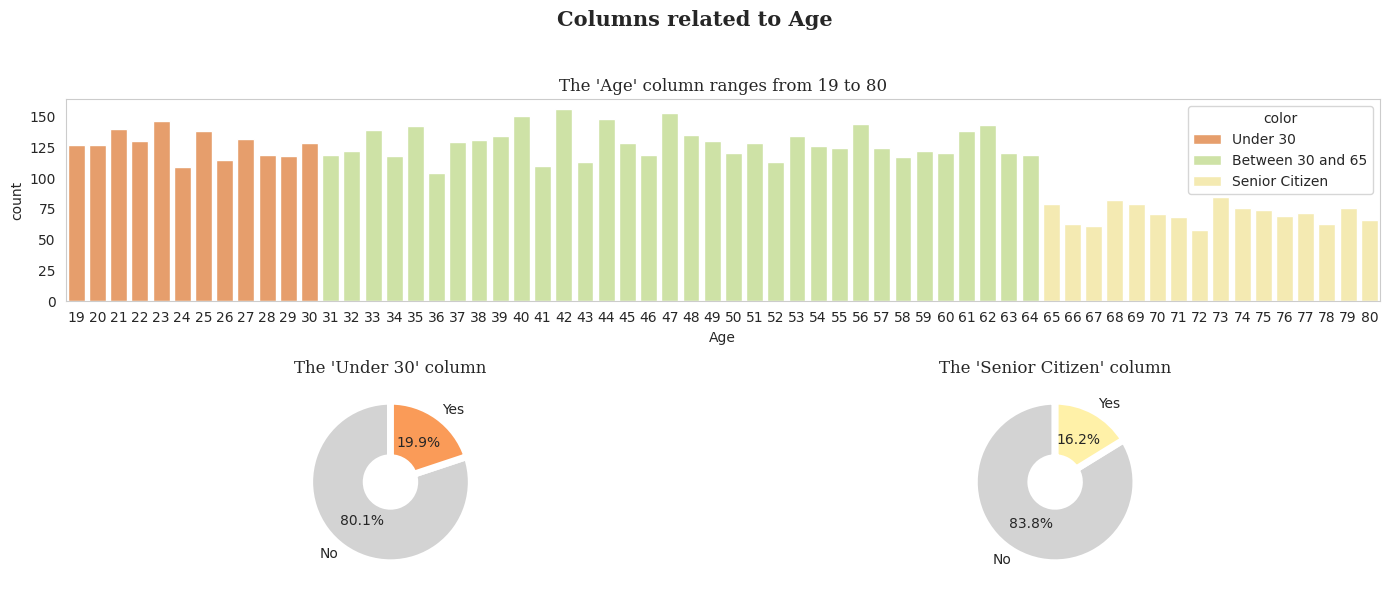

In [ ]:
# @title Age
plt.figure(figsize=(14, 6))
plt.suptitle('Columns related to Age', fontfamily='serif', fontsize=15, fontweight='bold')

# Count plot for age
plt.subplot(2, 1, 1)

viz_age = raw_demographics[['Age']].value_counts().reset_index()
viz_age['color'] = 'Between 30 and 65'
viz_age.loc[viz_age['Age'] <= 30, 'color'] = 'Under 30'
viz_age.loc[viz_age['Age'] >= 65, 'color'] = 'Senior Citizen'

colors = {"Under 30": sns.color_palette("Spectral", 10)[2]
          , "Senior Citizen": sns.color_palette("Spectral", 10)[4]
          , "Between 30 and 65": sns.color_palette("Spectral", 10)[6]}

sns.barplot(data=viz_age
            , x='Age'
            , y='count'
            , hue='color'
            , palette=colors)
plt.title('The \'Age\' column ranges from 19 to 80', fontfamily='serif', fontsize=12)

# Donut chart for Under 30
plt.subplot(2, 2, 3)

under_30 = raw_demographics[['Under 30']].value_counts().reset_index()
under_30_colors = [colors['Under 30'] if val == "Yes" else "lightgrey" for val in under_30['Under 30']]

plt.pie(under_30['count']
        , labels=under_30['Under 30']
        , autopct='%1.1f%%'
        , startangle=90
        , wedgeprops = wedgeprops
        , colors=under_30_colors)
plt.title('The \'Under 30\' column', fontfamily='serif', fontsize=12)

# Donut chart for Senior Citizen
plt.subplot(2, 2, 4)

senior = raw_demographics[['Senior Citizen']].value_counts().reset_index()
senior_colors = [colors['Senior Citizen'] if val == "Yes" else "lightgrey" for val in senior['Senior Citizen']]
plt.pie(senior['count']
        , labels=senior['Senior Citizen']
        , autopct='%1.1f%%'
        , startangle=90
        , wedgeprops = wedgeprops
        , colors=senior_colors)
plt.title('The \'Senior Citizen\' column', fontfamily='serif', fontsize=12)

# Plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
tmp_anomaly = raw_demographics[['Under 30', 'Senior Citizen', 'Age']]
tmp_anomaly['is Under 30'] = tmp_anomaly['Age'] < 30
tmp_anomaly['is Senior Citizen'] = tmp_anomaly['Age'] >= 65
display(tmp_anomaly[['Under 30', 'is Under 30']].value_counts())
display(tmp_anomaly[['Senior Citizen', 'is Senior Citizen']].value_counts())

<ipython-input-21-131d329d7546>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_anomaly['is Under 30'] = tmp_anomaly['Age'] < 30
<ipython-input-21-131d329d7546>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_anomaly['is Senior Citizen'] = tmp_anomaly['Age'] >= 65


,,count
Under 30,is Under 30,
No,False,5642
Yes,True,1401


,,count
Senior Citizen,is Senior Citizen,
No,False,5901
Yes,True,1142


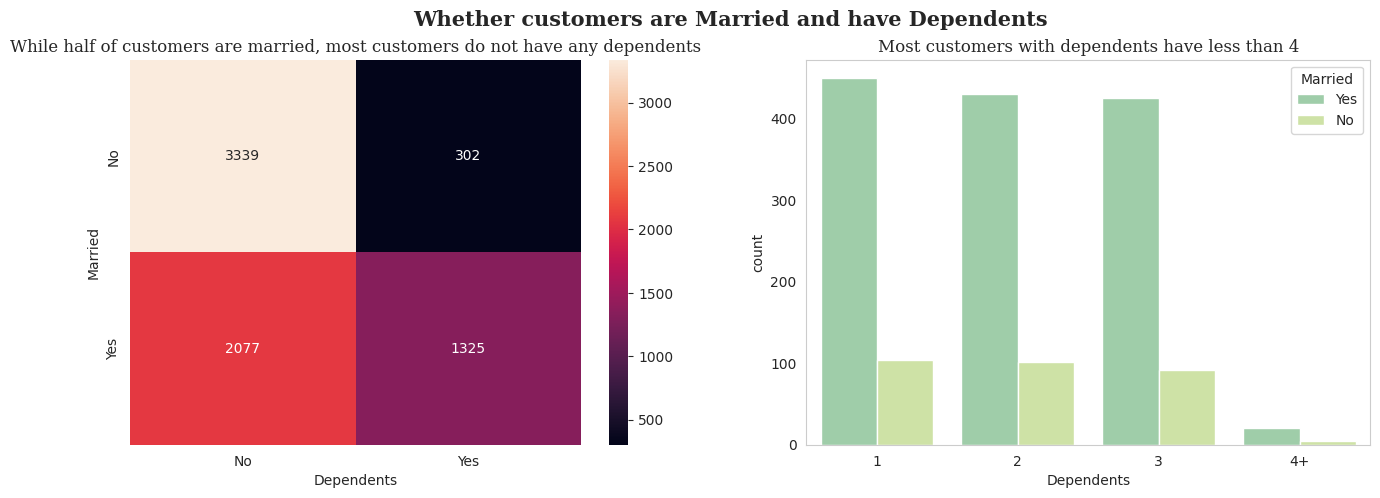

In [ ]:
# @title Family
plt.figure(figsize=(16, 5))
plt.suptitle('Whether customers are Married and have Dependents'
             , fontfamily='serif', fontsize=15, fontweight='bold')

plt.subplot(1, 2, 1)

contingency_table = pd.crosstab(raw_demographics['Married'], raw_demographics['Dependents'])

sns.heatmap(contingency_table, annot=True, fmt='d')
plt.title('While half of customers are married, most customers do not have any dependents', fontfamily='serif', fontsize=12)

plt.subplot(1, 2, 2)

dependents = raw_demographics[raw_demographics['Number of Dependents']>0][['Married', 'Number of Dependents']]
dependents['Dependents'] = dependents['Number of Dependents'].astype('str')
dependents.loc[dependents['Number of Dependents'] >= 4, 'Dependents'] = '4+'

sns.countplot(data=dependents, x='Dependents', hue='Married', order=['1', '2', '3', '4+'])
plt.title('Most customers with dependents have less than 4', fontfamily='serif', fontsize=12)

plt.show()

## location
|Column Name|Description|Type|Value|
|---|---|---|---|
|Location ID|A unique ID that identifies each cutomer location|string||
|Customer ID|A unique ID that identifies each customer|string||
|Count|A value used in reporting/dashboarding to sum up the number of customers in a filtered set|int|1|
|Country|The country of the customer’s primary residence|string|United States|
|State|The state of the customer’s primary residence|string|California|
|City|The city of the customer’s primary residence|string|Los Angeles, San Diego...|
|Zip Code|The zip code of the customer’s primary residence|int|6 digits|
|Lat Long|The combined latitude and longitude of the customer’s primary residence|string|*Latitude value*, *Longitude value*|
|Latitude|The latitude of the customer’s primary residence|float||
|Longitude|The longitude of the customer’s primary residence|float||


In [ ]:
# @title Overview

display(raw_location.sample(3))
display(raw_location.info())

,Location ID,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
6001,BMLXUJ4248,8124-NZVGJ,1,United States,California,Baker,92309,"35.28952, -116.092214",35.289520,-116.092214
4612,UMQAPN3919,3896-ZVNET,1,United States,California,Gerber,96035,"40.03194, -122.176023",40.031940,-122.176023
5515,EPPNXQ5464,4338-EYCER,1,United States,California,Carlotta,95528,"40.497283, -123.93037",40.497283,-123.930370


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location ID  7043 non-null   object 
 1   Customer ID  7043 non-null   object 
 2   Count        7043 non-null   int64  
 3   Country      7043 non-null   object 
 4   State        7043 non-null   object 
 5   City         7043 non-null   object 
 6   Zip Code     7043 non-null   int64  
 7   Lat Long     7043 non-null   object 
 8   Latitude     7043 non-null   float64
 9   Longitude    7043 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 550.4+ KB


None

In [ ]:
# @title Missing Values
# @markdown There are no missing values in the location table

# display(msno.matrix(raw_location))
display(raw_location.isna().sum())


,0
Location ID,0
Customer ID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0


In [ ]:
# @title Location ID
# @markdown Location ID seems to be a unique ID for each customer.

raw_location['Location ID'].value_counts()

,count
Location ID,
OXCZEW7397,1
TESTEH5496,1
JJUNOY6288,1
FWFFDG5618,1
HHFXFS1464,1
...,...
HCWBCF5627,1
SRKKHA2316,1
NWWFLR4535,1


In [ ]:
# @title Customer ID
# @markdown Customer ID of location and demographic table are the same. Both tables each have 7043 rows.

print('Unique customer IDs in location and demographic tables: ', len(pd.merge(raw_demographics['Customer ID'], raw_location['Customer ID'])))


Unique customer IDs in location and demographic tables:  7043


In [ ]:
# @title Country, State, City
# @markdown All rows have the same Country(United States) and State(California), and there are 1106 cities.

raw_location[['Country', 'State', 'City', 'Count']].groupby(['Country', 'State', 'City']).count().sort_values(by='Count', ascending=False)


Count
Country       State      City                   
United States California Los Angeles         293
                         San Diego           285
                         San Jose            112
                         Sacramento          108
                         San Francisco       104
...                                          ...
                         South Lake Tahoe      2
                         Jacumba               2
                         Johannesburg          2
                         Holtville             2
                         Eldridge              2

[1106 rows x 1 columns]

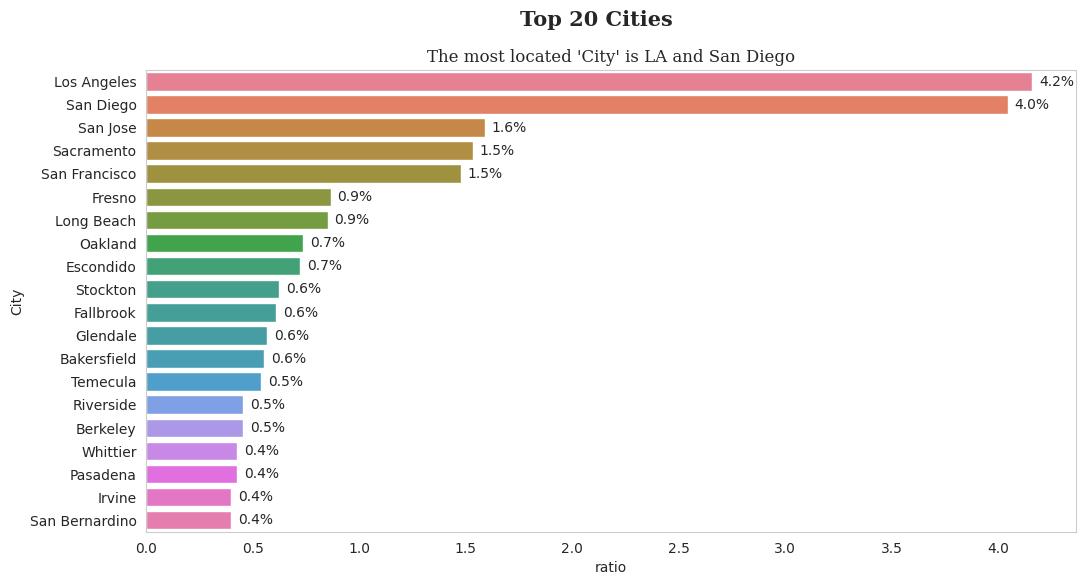

In [ ]:
# @title Top 20 cities
city = raw_location.City.value_counts().reset_index()
city['ratio'] = city['count'] /sum(city['count']) * 100
city = city.sort_values(by='ratio', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=city.head(20), x='ratio', y='City', hue='City')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2),  # position text at the center of each bar
                ha='left', va='center',  # horizontal and vertical alignment
                xytext=(5, 0),  # offset text 5 points to the right
                textcoords='offset points')  # coordinates are relative to the bar

plt.suptitle('Top 20 Cities', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('The most located \'City\' is LA and San Diego', fontfamily='serif', fontsize=12)

plt.show()

In [ ]:
# @title Zip code
# @markdown Zip code is not unique to city. One city might have several zip codes, but not vice versa.
raw_location[['City', 'Zip Code']].drop_duplicates().groupby(['City', 'Zip Code']).count().sort_values(by='Zip Code')

Empty DataFrame
Columns: []
Index: [(Los Angeles, 90001), (Los Angeles, 90002), (Los Angeles, 90003), (Los Angeles, 90004), (Los Angeles, 90005), (Los Angeles, 90006), (Los Angeles, 90007), (Los Angeles, 90008), (Los Angeles, 90010), (Los Angeles, 90011), (Los Angeles, 90012), (Los Angeles, 90013), (Los Angeles, 90014), (Los Angeles, 90015), (Los Angeles, 90016), (Los Angeles, 90017), (Los Angeles, 90018), (Los Angeles, 90019), (Los Angeles, 90021), (Los Angeles, 90022), (Los Angeles, 90023), (Los Angeles, 90024), (Los Angeles, 90025), (Los Angeles, 90026), (Los Angeles, 90027), (Los Angeles, 90028), (Los Angeles, 90029), (Los Angeles, 90031), (Los Angeles, 90032), (Los Angeles, 90033), (Los Angeles, 90034), (Los Angeles, 90035), (Los Angeles, 90036), (Los Angeles, 90037), (Los Angeles, 90038), (Los Angeles, 90039), (Los Angeles, 90040), (Los Angeles, 90041), (Los Angeles, 90042), (Los Angeles, 90043), (Los Angeles, 90044), (Los Angeles, 90045), (Los Angeles, 90046), (Los Angeles, 90047), (Los Angeles, 90048), (Los Angeles, 90049), (Los Angeles, 90056), (Los Angeles, 90057), (Los Angeles, 90058), (Los Angeles, 90059), (Los Angeles, 90061), (Los Angeles, 90062), (Los Angeles, 90063), (Los Angeles, 90064), (Los Angeles, 90065), (Los Angeles, 90066), (Los Angeles, 90067), (Los Angeles, 90068), (West Hollywood, 90069), (Los Angeles, 90071), (Los Angeles, 90077), (Bell, 90201), (Beverly Hills, 90210), (Beverly Hills, 90211), (Beverly Hills, 90212), (Compton, 90220), (Compton, 90221), (Compton, 90222), (Culver City, 90230), (Culver City, 90232), (Downey, 90240), (Downey, 90241), (Downey, 90242), (El Segundo, 90245), (Gardena, 90247), (Gardena, 90248), (Gardena, 90249), (Hawthorne, 90250), (Hermosa Beach, 90254), (Huntington Park, 90255), (Lawndale, 90260), (Lynwood, 90262), (Malibu, 90263), (Malibu, 90265), (Manhattan Beach, 90266), (Maywood, 90270), (Pacific Palisades, 90272), (Palos Verdes Peninsula, 90274), (Rancho Palos Verdes, 90275), (Redondo Beach, 90277), (Redondo Beach, 90278), (South Gate, 90280), (Topanga, 90290), (Venice, 90291), (Marina Del Rey, 90292), (Playa Del Rey, 90293), (Inglewood, 90301), (Inglewood, 90302), (Inglewood, 90303), (Inglewood, 90304), ...]

[1626 rows x 0 columns]

https://www.unitedstateszipcodes.org/ca/

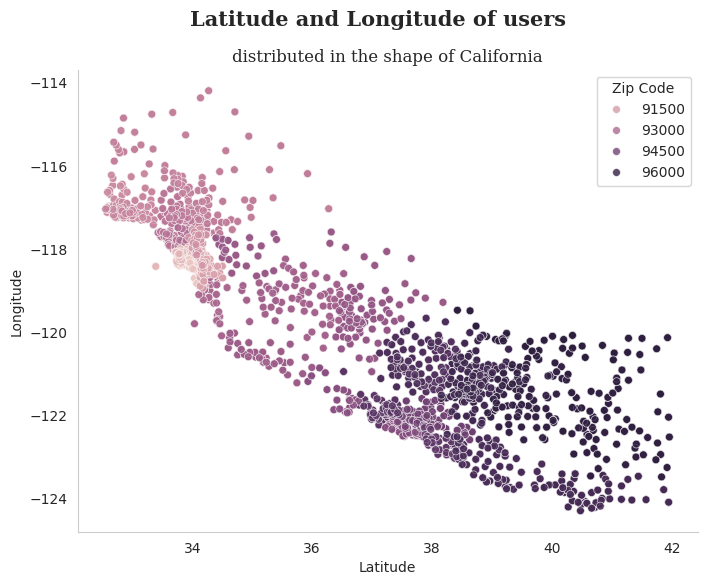

In [ ]:
# @title Latitude vs Longitude

plt.figure(figsize=(8, 6))
sns.scatterplot(data=raw_location, x='Latitude', y='Longitude', s=32, alpha=.8, hue='Zip Code')
plt.suptitle('Latitude and Longitude of users', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('distributed in the shape of California', fontfamily='serif', fontsize=12)
plt.gca().spines[['top', 'right',]].set_visible(False)

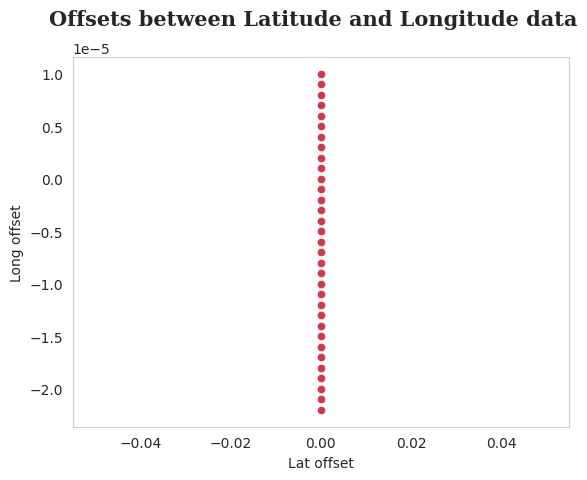

In [ ]:
# @title Duplicate column check (Lang Long)
tmp = raw_location['Lat Long'].str.split(',', expand=True).rename(columns={0: 'Lat', 1:'Long'})
tmp[['Lat', 'Long']] = tmp[['Lat', 'Long']].apply(pd.to_numeric, errors='coerce')

tmp = pd.concat([raw_location[['Latitude', 'Longitude']], tmp], axis=1)
tmp['Lat offset'] = tmp['Latitude'] - tmp['Lat']
tmp['Long offset'] = tmp['Longitude'] - tmp['Long']

plt.suptitle('Offsets between Latitude and Longitude data', fontfamily='serif', fontsize=15, fontweight='bold')
sns.scatterplot(x='Lat offset', y='Long offset', data=tmp)

plt.show()

We can see that the lattitude data is identical between columns.  
However, The longitude shows slight differences.

To check whether this difference can be ignored, we can calculate the distance between the two locations indicated with the *Latitude* column and *Lonitude* column, and the *Lat Long* column.

This can be done using the formula below.

$$
d = 111320 \cdot \cos(\phi) \cdot \Delta \lambda\
$$

where
- $d$ is the distance in **meters**
- $\phi$ is the latitude in degrees
- $\Delta \lambda $ is the difference in longitude in degrees


In [ ]:
tmp['distance'] = 111320 * np.cos(np.radians(tmp['Latitude'])) * np.abs(tmp['Longitude'] - tmp['Long'])
tmp['distance'].describe()

,distance
count,7043.000000
mean,0.007159
std,0.096219
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.058863


We can see that the maximum difference is merely 2 meters, where the average distance is 0.7 centimeters.  
In conclusion, it seems there will be no problem in ignoring the redundant columns.

## Population
|Column Name|Description|Type|Value|
|---|---|---|---|
|ID|A unique ID that identifies each row|int|index in table|
|Zip Code|The zip code of the customer’s primary residence|int|6 digit|
|Population|A current population estimate for the entire Zip Code area|int||

In [ ]:
# @title Overview

display(raw_population.sample(3))
display(raw_population.info())

,ID,Zip Code,Population
1208,1209,95330,10834
909,910,94080,60599
220,221,91381,9937


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          1671 non-null   int64
 1   Zip Code    1671 non-null   int64
 2   Population  1671 non-null   int64
dtypes: int64(3)
memory usage: 39.3 KB


None

In [ ]:
# @title Missing Values
# @markdown There are no missing values in the population table

# display(msno.matrix(raw_population))
display(raw_population.isna().sum())


,0
ID,0
Zip Code,0
Population,0


In [ ]:
# @title ID
# @markdown ID is duuplicate of index

In [ ]:
# @title Zip Code (vs locations table)
zip_codes = pd.merge(left=raw_population['Zip Code'], right=raw_location['Zip Code'], how='left', indicator=True)
zip_codes['_merge'].value_counts()

,count
_merge,
both,7043
left_only,46
right_only,0


We can see that the population table contains all data for zip codes existing in the locations table.  
46 zip codes exist in the population table that we will not use.

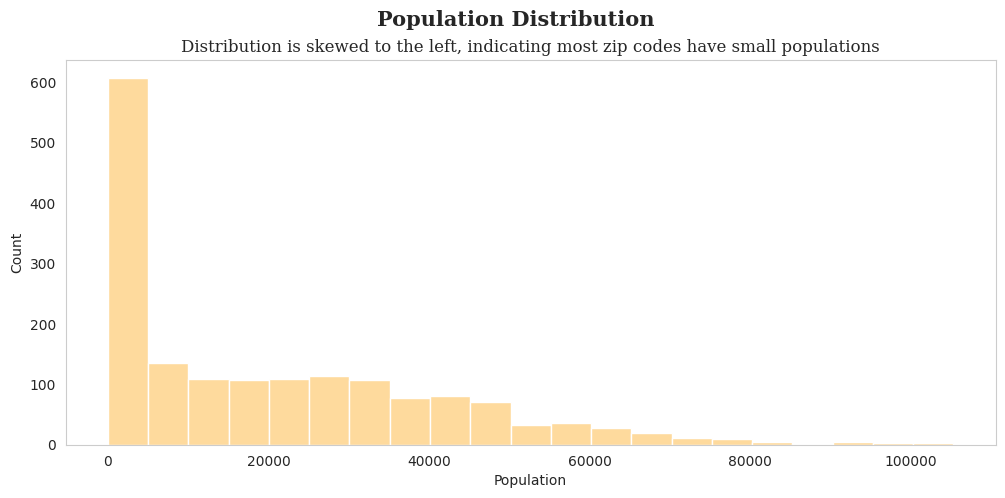

In [ ]:
# @title Population distribution
plt.figure(figsize=(12, 5))

sns.histplot(data=raw_population, x='Population')
plt.suptitle('Population Distribution', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('Distribution is skewed to the left, indicating most zip codes have small populations', fontfamily='serif', fontsize=12)

plt.show()

## services

|Column Name|Description|Type|Value|
|---|---|---|---|
|Service ID|A unique ID that identifies each service|string||
|Customer ID|A unique ID that identifies each customer|string||
|Count|A value used in reporting/dashboarding to sum up the number of customers in a filtered set|int|1|
|Quarter|The fiscal quarter that the data has been derived from|string|Q3|
|Referred a Friend|Indicates if the customer has ever referred a friend or family member to this company||Yes, No|
|Number of Referrals|Indicates the number of referrals to date that the customer has made|||
|Tenure in Months|Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above||||
|Offer|Identifies the last marketing offer that the customer accepted, if applicable||None, Offer A, Offer B, Offer C, Offer D, Offer E|
|Phone Service|Indicates if the customer subscribes to home phone service with the company||Yes, No|
|Avg Monthly Long Distance Charges|Indicates the customer’s average long distance charges, calculated to the end of the quarter specified above|||
|Multiple Lines|Indicates if the customer subscribes to multiple telephone lines with the company||Yes, No|
|Internet Service|Indicates if the customer subscribes to Internet service with the company||Yes, No|
|Internet Type|Type of internet type the customer subscribes to|String|DSL, Fiber Optic, Cable|
|Avg Monthly GB Download|Indicates the customer’s average download volume in gigabytes, calculated to the end of the quarter specified above|||
|Online Security|Indicates if the customer subscribes to an additional online security service provided by the company||Yes, No|
|Online Backup|Indicates if the customer subscribes to an additional online backup service provided by the company||Yes, No|
|Device Protection Plan|Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company||Yes, No|
|Premium Tech Support|Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times||Yes, No|
|Streaming TV|Indicates if the customer uses their Internet service to stream television programing from a third party provider||Yes, No|
|Streaming Movies|Indicates if the customer uses their Internet service to stream movies from a third party provider||Yes, No|
|Streaming Music|Indicates if the customer uses their Internet service to stream music from a third party provider: ||Yes, No|
|Unlimited Data|Indicates if the customer has paid an additional monthly fee to have unlimited data downloads/uploads||Yes, No|
|Contract|Indicates the customer’s current contract type||Month-to-Month, One Year, Two Year|
|Paperless Billing|Indicates if the customer has chosen paperless billing||Yes, No|
|Payment Method|Indicates how the customer pays their bill||Bank Withdrawal, Credit Card, Mailed Check|
|Monthly Charge|Indicates the customer’s current total monthly charge for all their services from the company|||
|Total Charges|Indicates the customer’s total charges, calculated to the end of the quarter specified above|||
|Total Refunds|Indicates the customer’s total refunds, calculated to the end of the quarter specified above|||
|Total Extra Data Charges|Indicates the customer’s total charges for extra data downloads above those specified in their plan, by the end of the quarter specified above|||
|Total Long Distance Charges|Indicates the customer’s total charges for long distance above those specified in their plan, by the end of the quarter specified above|||
|Total Revenue|total_charges - total_refunds + total_extra_data_charges + total_long_distance_charges|||


In [ ]:
# @title Overview

display(raw_services.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Service ID                         7043 non-null   object 
 1   Customer ID                        7043 non-null   object 
 2   Count                              7043 non-null   int64  
 3   Quarter                            7043 non-null   object 
 4   Referred a Friend                  7043 non-null   object 
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              3166 non-null   object 
 8   Phone Service                      7043 non-null   object 
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   object 
 11  Internet Service                   7043 non-null   objec

None

<Axes: >

,0
Service ID,0
Customer ID,0
Count,0
Quarter,0
Referred a Friend,0
Number of Referrals,0
Tenure in Months,0
Offer,3877
Phone Service,0
Avg Monthly Long Distance Charges,0


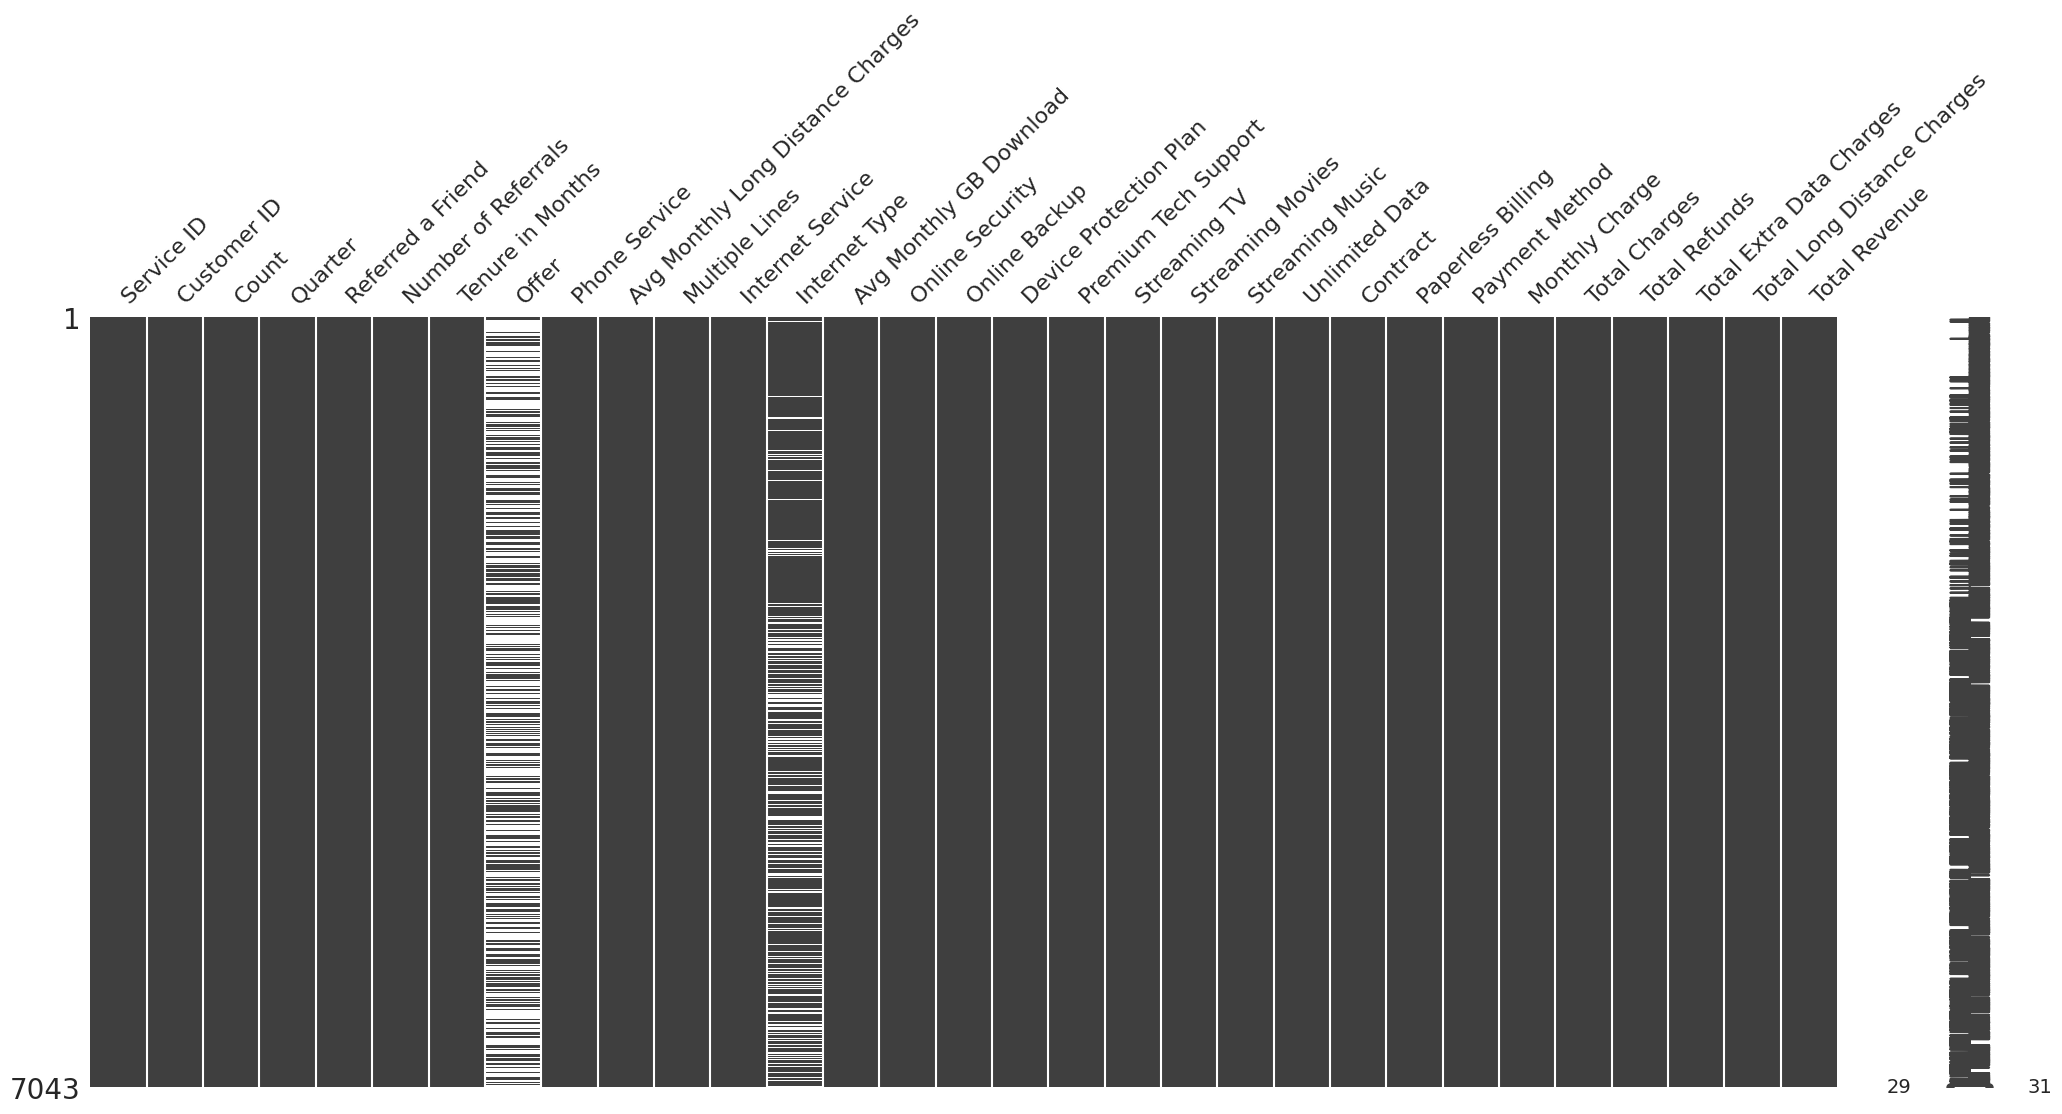

In [ ]:
# @title Missing Values
# @markdown There are missing values in 2 columns of the services table that need processing

display(msno.matrix(raw_services))
display(raw_services.isna().sum())

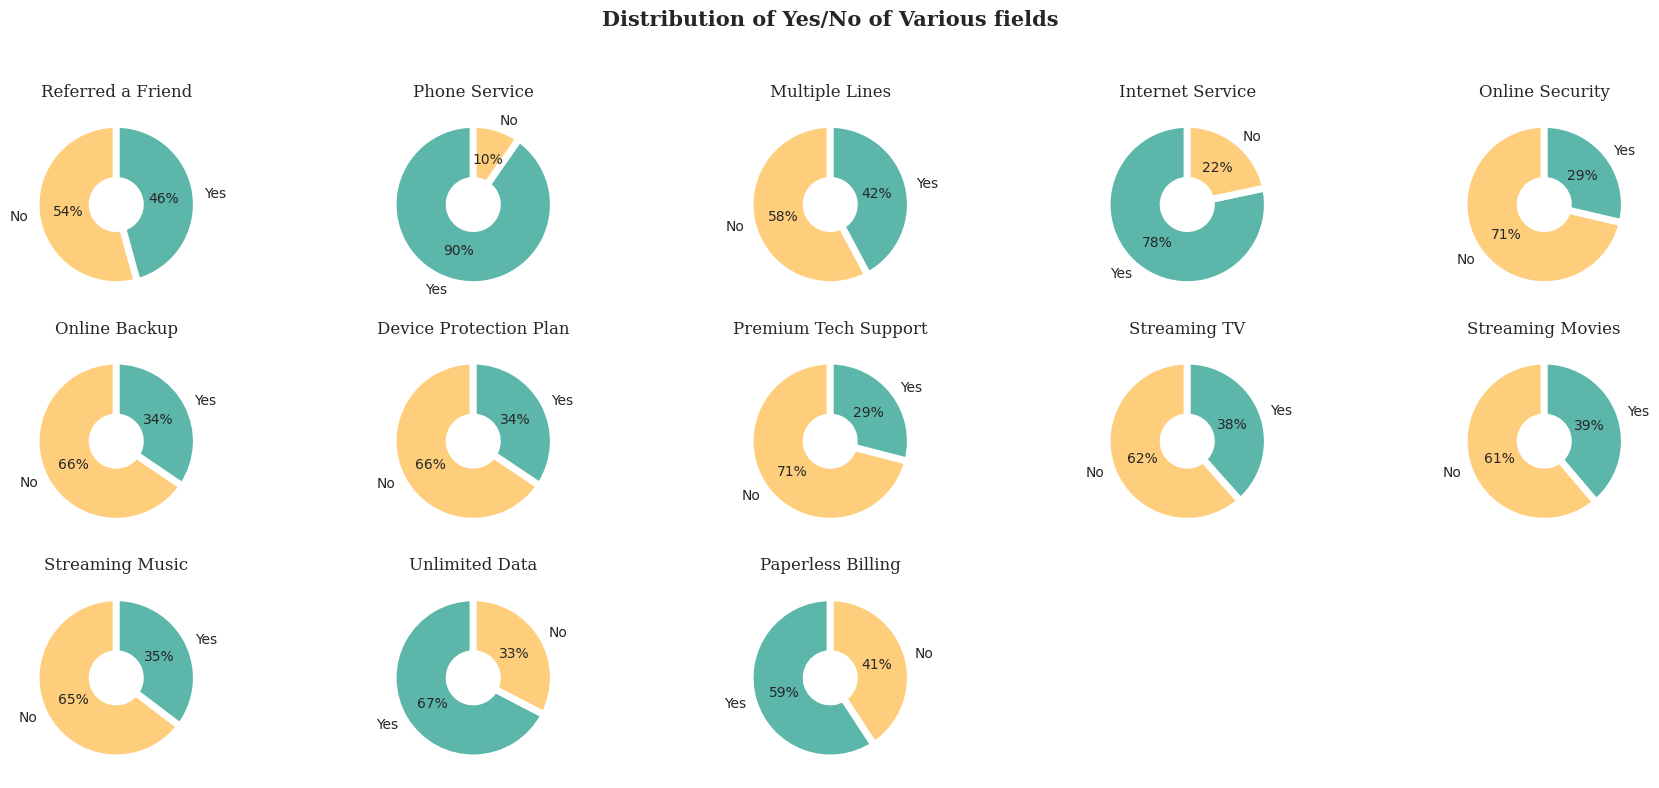

In [ ]:
# @title Boolean columns
services_boolean = ['Referred a Friend'
, 'Phone Service'
, 'Multiple Lines'
, 'Internet Service'
, 'Online Security'
, 'Online Backup'
, 'Device Protection Plan'
, 'Premium Tech Support'
, 'Streaming TV'
, 'Streaming Movies'
, 'Streaming Music'
, 'Unlimited Data'
, 'Paperless Billing']

colors = {"Yes": sns.color_palette("Spectral", 10)[8], "No": sns.color_palette("Spectral", 10)[3]}

# Boolean fields
plt.figure(figsize=(18, 8))
plt.suptitle('Distribution of Yes/No of Various fields', fontfamily='serif', fontsize=15, fontweight='bold')

for i in range(len(services_boolean)):
  col = services_boolean[i]
  pie = raw_services[col].value_counts().reset_index()
  pie_colors = [colors[label] for label in pie[col]]

  # plot
  plt.subplot(3, 5, i+1)

  plt.pie(pie['count']
          , labels=pie[col]
          , autopct='%.0f%%'
          , wedgeprops = wedgeprops
          , startangle=90
          , colors=pie_colors)
  plt.title(col, fontfamily='serif', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Some fields have a distinct trend in their distribution, where more than two thirds are of the same type.
- 90% of users have phone service
- 78% of users have internet service
- 71% of users do *not* have online security
- 71% of users do *not* have premium tech support
- 67% of users have unlimited data
- 66% of users do *not* have online backup
- 66% of users do *not* have device protection plan

Other fields have somewhat balanced distribution.
- 65% of users do *not* have streaming music
- 62% of users do *not* have streaming TV
- 61% of users do *not* have streaning movies
- 59% of users have paperless billing
- 58% of users do *not* have multiple lines
- 54% of users have *not* referred to a friend

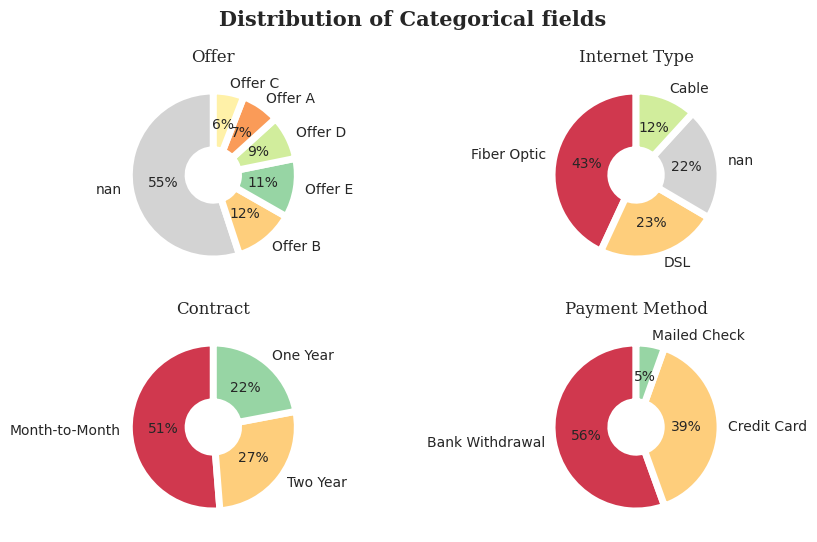

In [ ]:
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

# @title Categorical columns
services_categorical = ['Offer'
, 'Internet Type'
, 'Contract'
, 'Payment Method']

# Categorical fields
plt.figure(figsize=(10, 6))
plt.suptitle('Distribution of Categorical fields', fontfamily='serif', fontsize=15, fontweight='bold')


for i in range(len(services_categorical)):
  col = services_categorical[i]
  pie = raw_services[col].value_counts(dropna=False).reset_index()
  colors = [
    'lightgrey' if pd.isna(value) else sns.color_palette()[i % 10]
    for i, value in enumerate(pie[col])]

  # plot
  plt.subplot(2, 2, i+1)

  plt.pie(pie['count']
          , labels=pie[col]
          , autopct='%.0f%%'
          , wedgeprops = wedgeprops
          , startangle=90
          , colors=colors)
  plt.title(col, fontfamily='serif', fontsize=12)

plt.show()

The **Offer** and **Internet Type** field has NaN values
- 55% of the users did not accept any marketing offer
- 22% of the users does not subscribe any internet service, which can be also checked in the 'Internet Service' field

In [ ]:
# @title Numerical columns

service_numerical = ['Number of Referrals'
, 'Tenure in Months'
, 'Avg Monthly Long Distance Charges'
, 'Avg Monthly GB Download'
, 'Monthly Charge'
, 'Total Charges'
, 'Total Refunds'
, 'Total Extra Data Charges'
, 'Total Long Distance Charges'
, 'Total Revenue']

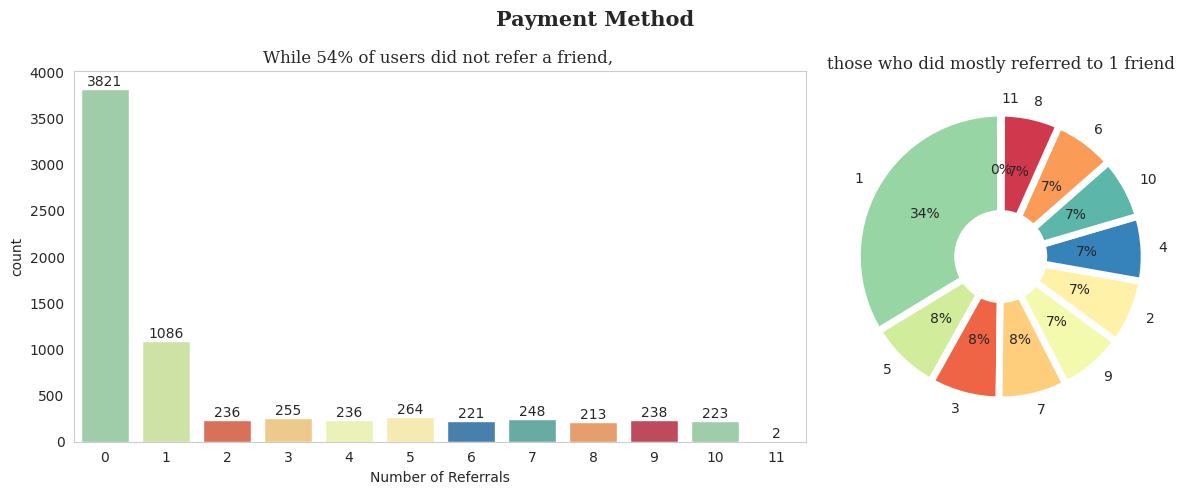

In [ ]:
# @title Number of Referrals
plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(1, 3)

viz_data = raw_services['Number of Referrals'].value_counts().reset_index()
colors = [sns.color_palette()[i % 10] for i, value in enumerate(viz_data['Number of Referrals'])]

plt.subplot(gs[0, :2])
ax = sns.barplot(data=viz_data
                 , x='Number of Referrals'
                 , y='count'
                 , palette=colors
                 , hue='Number of Referrals'
                 , legend=False)

for bar in ax.patches:
    bar_height = bar.get_height()  # Get the height of the bar
    bar_x = bar.get_x() + bar.get_width() / 2  # Get the x-coordinate of the bar's center
    ax.text(bar_x, bar_height + 1,  # Position above the bar
            f'{bar_height:.0f}',  # Display the height as an integer
            ha='center', va='bottom',
            fontsize=10)

plt.title('While 54% of users did not refer a friend, ', fontfamily='serif', fontsize=12)

plt.subplot(gs[0, 2])
viz_pie = raw_services[raw_services['Number of Referrals'] > 0].value_counts('Number of Referrals').reset_index()
plt.pie(viz_pie['count']
        , labels=viz_pie['Number of Referrals']
        , autopct='%.0f%%'
        , wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
        , startangle=90
        , colors=colors)
plt.title('those who did mostly referred to 1 friend', fontfamily='serif', fontsize=12)

plt.tight_layout()
plt.show()

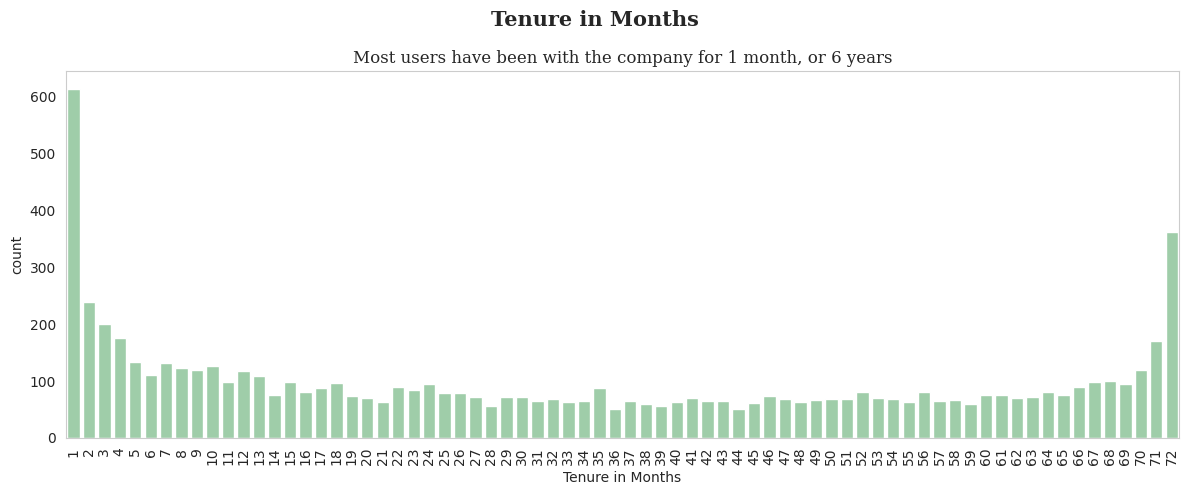

In [ ]:
# @title Tenure in Months
col = 'Tenure in Months'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.barplot(data=raw_services[col].value_counts().reset_index()
                 , x=col
                 , y='count')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

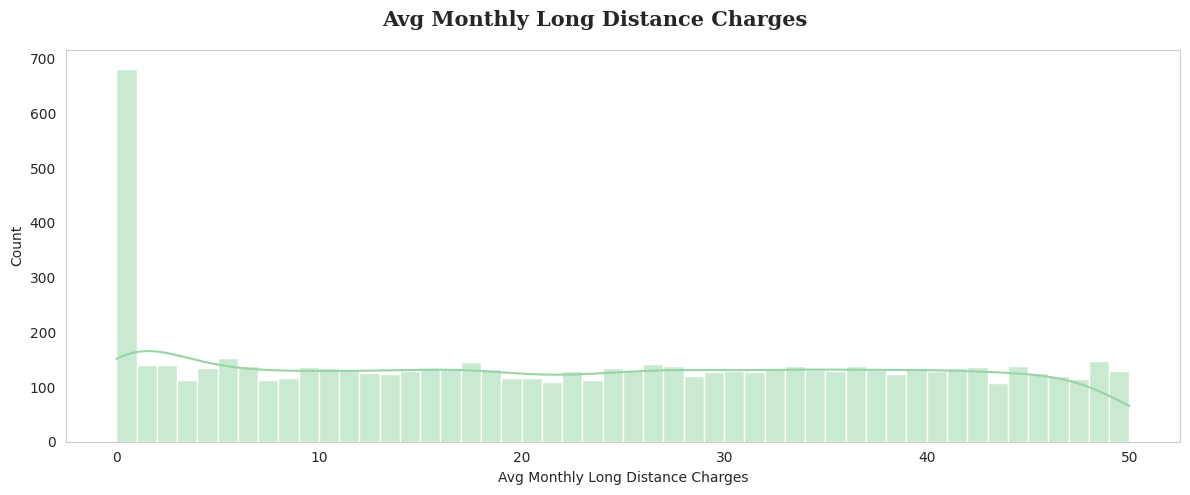

In [ ]:
# @title Avg Monthly Long Distance Charges
col = 'Avg Monthly Long Distance Charges'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
# plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

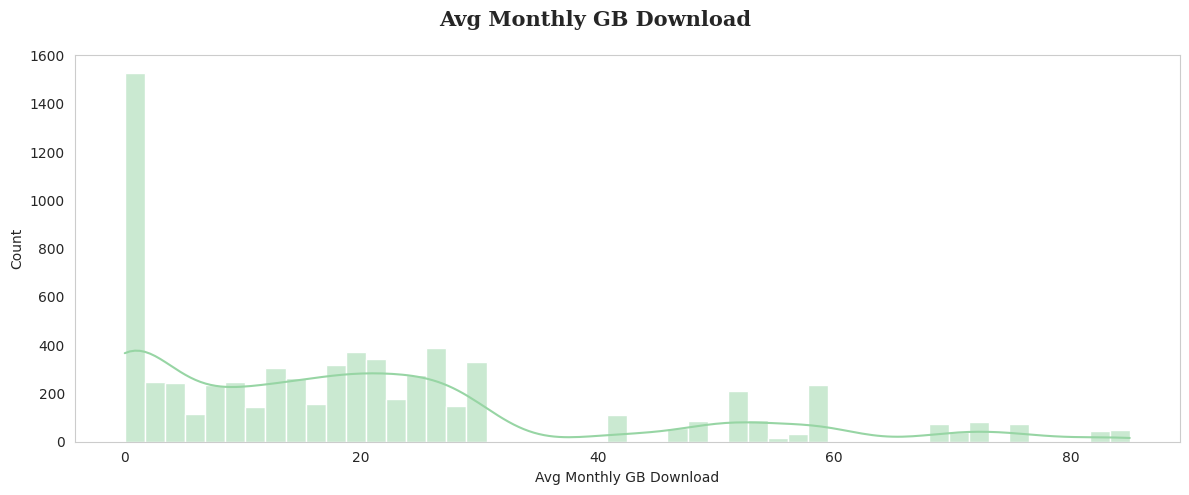

In [ ]:
# @title Avg Monthly GB Download
col = 'Avg Monthly GB Download'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
# plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

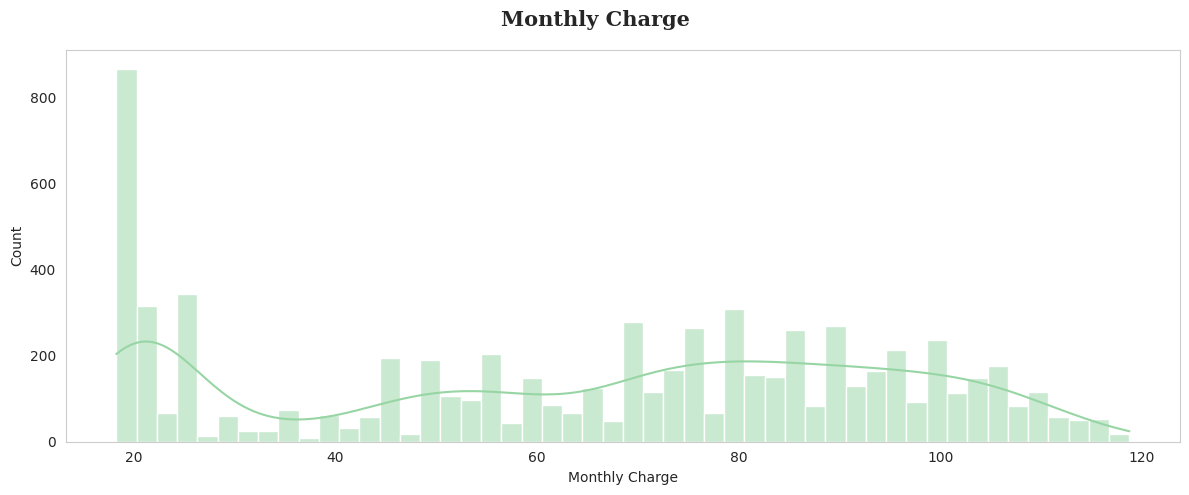

In [ ]:
# @title Monthly Charge
col = 'Monthly Charge'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
# plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

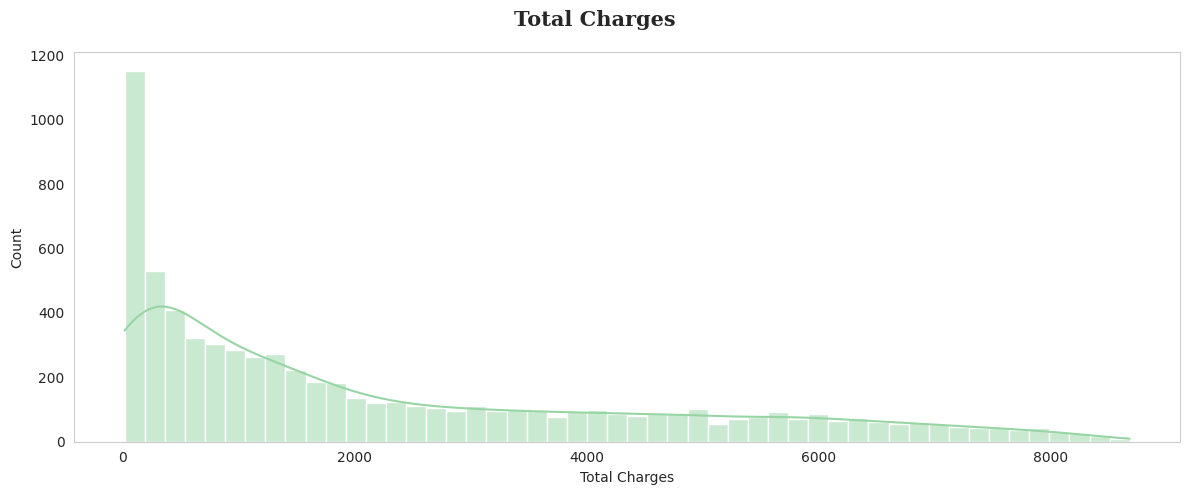

In [ ]:
# @title Total Charges
col = 'Total Charges'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
# plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

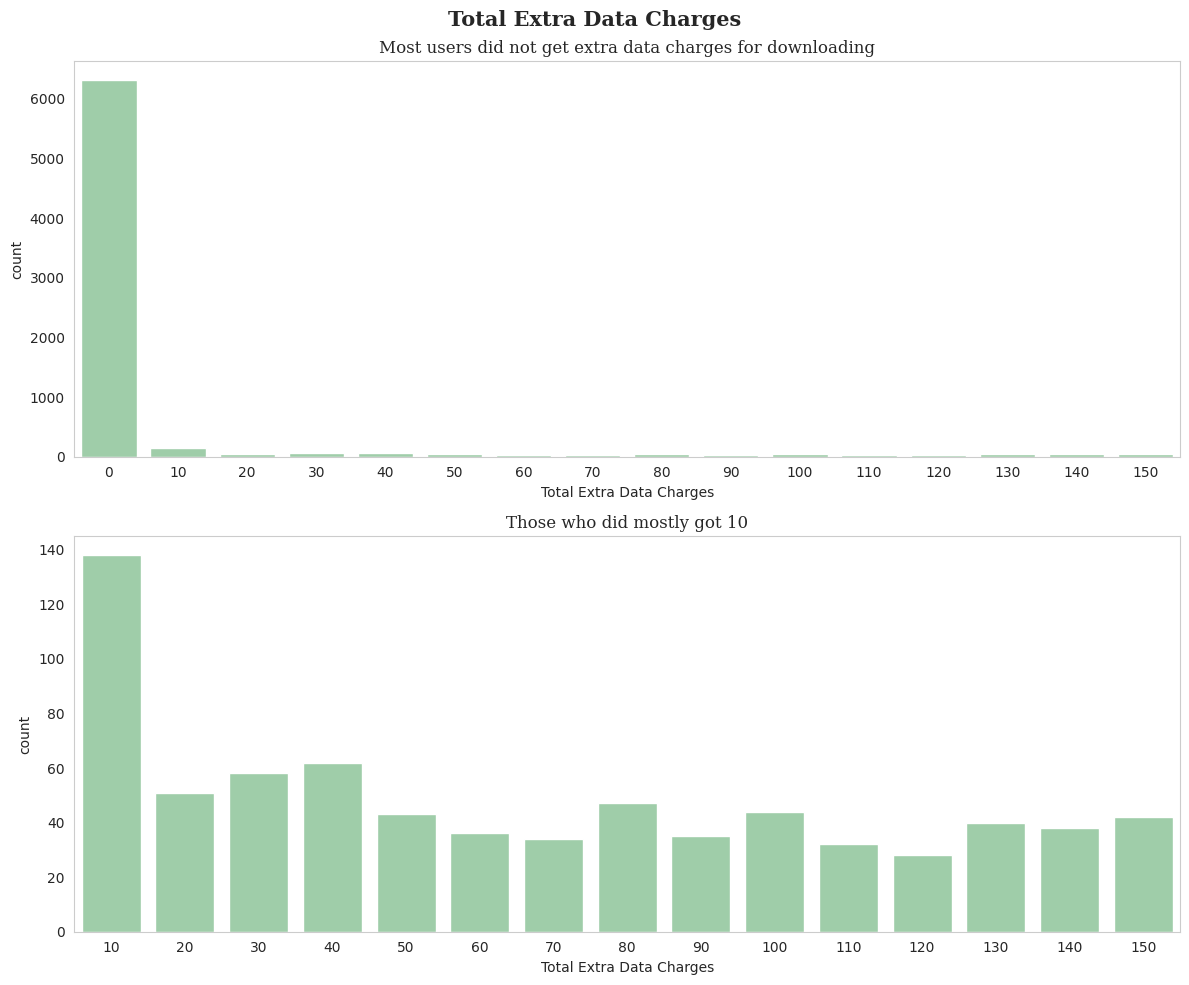

In [ ]:
# @title Total Extra Data Charges
col = 'Total Extra Data Charges'
viz_tmp = raw_services[col].value_counts().reset_index()

plt.figure(figsize=(12, 10))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')

plt.subplot(2, 1, 1)
plt.title('Most users did not get extra data charges for downloading', fontfamily='serif', fontsize=12)
sns.barplot(data=viz_tmp
             , x=col, y='count')

plt.subplot(2, 1, 2)
plt.title('Those who did mostly got 10', fontfamily='serif', fontsize=12)
sns.barplot(data=viz_tmp[viz_tmp[col] > 0]
             , x=col, y='count')

plt.tight_layout()
plt.show()


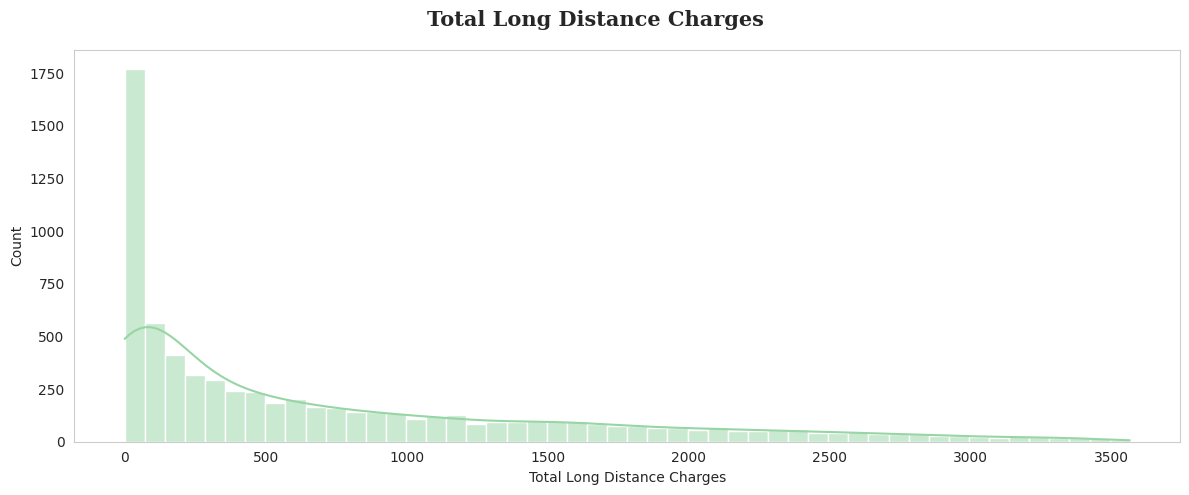

In [ ]:
# @title Total Long Distance Charges
col = 'Total Long Distance Charges'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')
# plt.title('Most users have been with the company for 1 month, or 6 years', fontfamily='serif', fontsize=12)

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

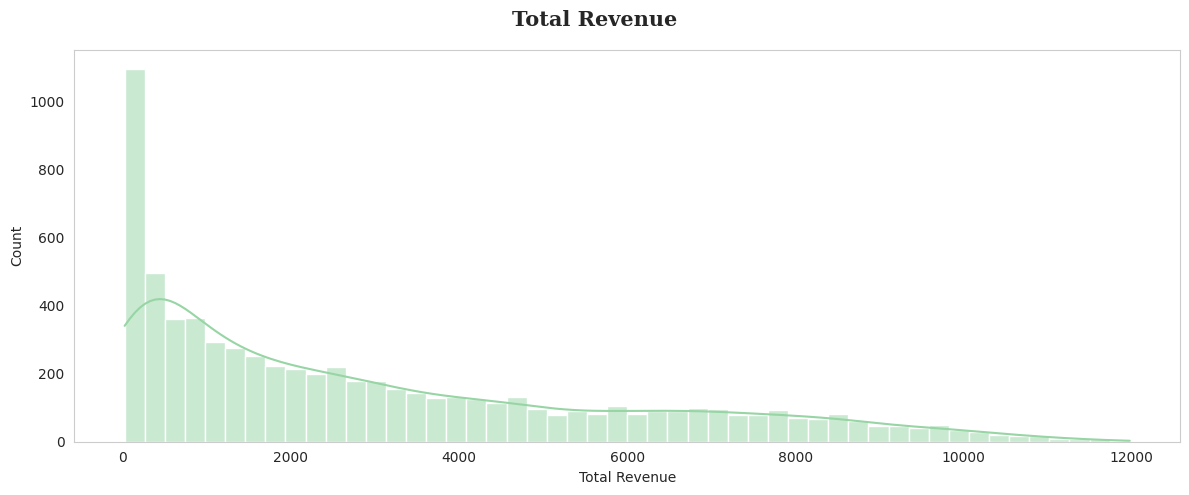

In [ ]:
# @title Total Revenue
col = 'Total Revenue'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

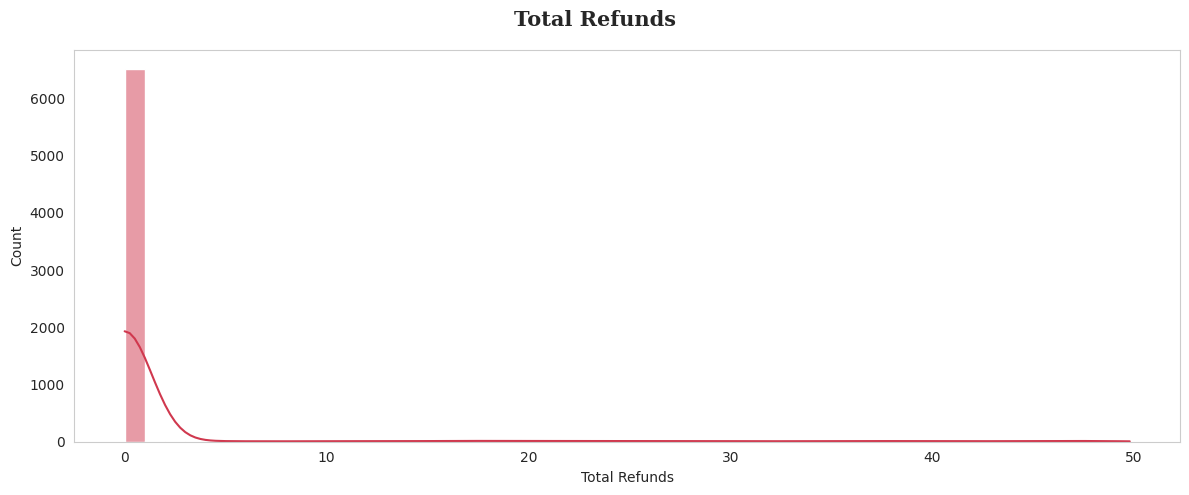

In [ ]:
# @title Total Revenue
col = 'Total Refunds'

plt.figure(figsize=(12, 5))
plt.suptitle(col, fontfamily='serif', fontsize=15, fontweight='bold')

sns.histplot(data=raw_services
             , x=col
             , bins=50
             , kde=True)
plt.tight_layout()
plt.show()

### Anomaly check
**Initial anomaly thoughts.**
- If 'Referred a Friend' is 'No', then 'Number of Referrals' should be 0, and vice versa.
- If 'Internet Service' is 'Yes', then 'Internet Type' should not be Null. If 'Internet Service' is 'No', then 'Internet Type' should be Null.
- 'Tenure in Months' should not be 0.
- 'Monthly Charge' and 'Total Charges' should not be 0.
- 'Total Charges' should be equal or larger than 'Monthly Charge'.
- 'Total Long Distance Charges' should be equal or larger than 'Avg Monthly Long Distance Charges'.
- If 'Avg Monthly GB Download' is 0, then 'Total Extra Data Charges' should be 0 (not vice versa).
- The sum of 'Total Charges', 'Total Extra Data Charges', and 'Total Long Distance Charges' subtracted by 'Total Refunds' should be 'Total Revenue'

In [ ]:
raw_services[['Referred a Friend', 'Number of Referrals']].value_counts()

Referred a Friend  Number of Referrals
No                 0                      3821
Yes                1                      1086
                   5                       264
                   3                       255
                   7                       248
                   9                       238
                   2                       236
                   4                       236
                   10                      223
                   6                       221
                   8                       213
                   11                        2
Name: count, dtype: int64

In [ ]:
display(raw_services[raw_services['Internet Service']=='Yes']['Internet Type'].value_counts())
display(raw_services[raw_services['Internet Service']=='No']['Internet Type'].value_counts())

,count
Internet Type,
Fiber Optic,3035
DSL,1652
Cable,830


,count
Internet Type,


In [ ]:
raw_services[(raw_services['Tenure in Months']==0) | (raw_services['Monthly Charge']==0) | (raw_services['Total Charges']==0)]

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue


In [ ]:
raw_services[(raw_services['Total Charges'] < raw_services['Monthly Charge'])]

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue


In [ ]:
raw_services[(raw_services['Total Long Distance Charges'] < raw_services['Avg Monthly Long Distance Charges'])]

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue


In [ ]:
raw_services[(raw_services['Avg Monthly GB Download'] == 0) & (raw_services['Total Extra Data Charges'] != 0)]

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue


## status

|Column Name|Description|Type|Value|
|---|---|---|---|
|CustomerID|A unique ID that identifies each customer|||
|Count|A value used in reporting/dashboarding to sum up the number of customers in a filtered set|||
|Quarter|The fiscal quarter that the data has been derived from||Q3|
|Satisfaction Score|A customer’s overall satisfaction rating of the company||1, 2, 3, 4, 5|
|Customer Status|Indicates the status of the customer at the end of the quarter||Churned, Stayed, or Joined|
|Churn Label|Whether the customer left the company this quarter||Yes, No|
|Churn Value|Whether the customer left the company this quarter||1, 0|
|Churn Score|A value calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.||0-100|
|CLTV|Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.|||
|Churn Category|A high-level category for the customer’s reason for churning. When they leave the company, all customers are asked about their reasons for leaving. Directly related to Churn Reason||Attitude, Competitor, Dissatisfaction, Other, Price|
|Churn Reason|A customer’s specific reason for leaving the company|||


In [ ]:
# @title Overview

display(raw_status.sample(3))
display(raw_status.info())

,Status ID,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
4104,CWGEED2283,1357-MVDOZ,1,Q3,3,Stayed,No,0,71,2136,NaN,NaN
3728,UZWOWS6563,3062-ICYZQ,1,Q3,3,Stayed,No,0,20,5457,NaN,NaN
3543,FMFHQX7291,5014-WUQMG,1,Q3,3,Stayed,No,0,68,5793,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Status ID           7043 non-null   object
 1   Customer ID         7043 non-null   object
 2   Count               7043 non-null   int64 
 3   Quarter             7043 non-null   object
 4   Satisfaction Score  7043 non-null   int64 
 5   Customer Status     7043 non-null   object
 6   Churn Label         7043 non-null   object
 7   Churn Value         7043 non-null   int64 
 8   Churn Score         7043 non-null   int64 
 9   CLTV                7043 non-null   int64 
 10  Churn Category      1869 non-null   object
 11  Churn Reason        1869 non-null   object
dtypes: int64(5), object(7)
memory usage: 660.4+ KB


None

<Axes: >

,0
Status ID,0
Customer ID,0
Count,0
Quarter,0
Satisfaction Score,0
Customer Status,0
Churn Label,0
Churn Value,0
Churn Score,0
CLTV,0


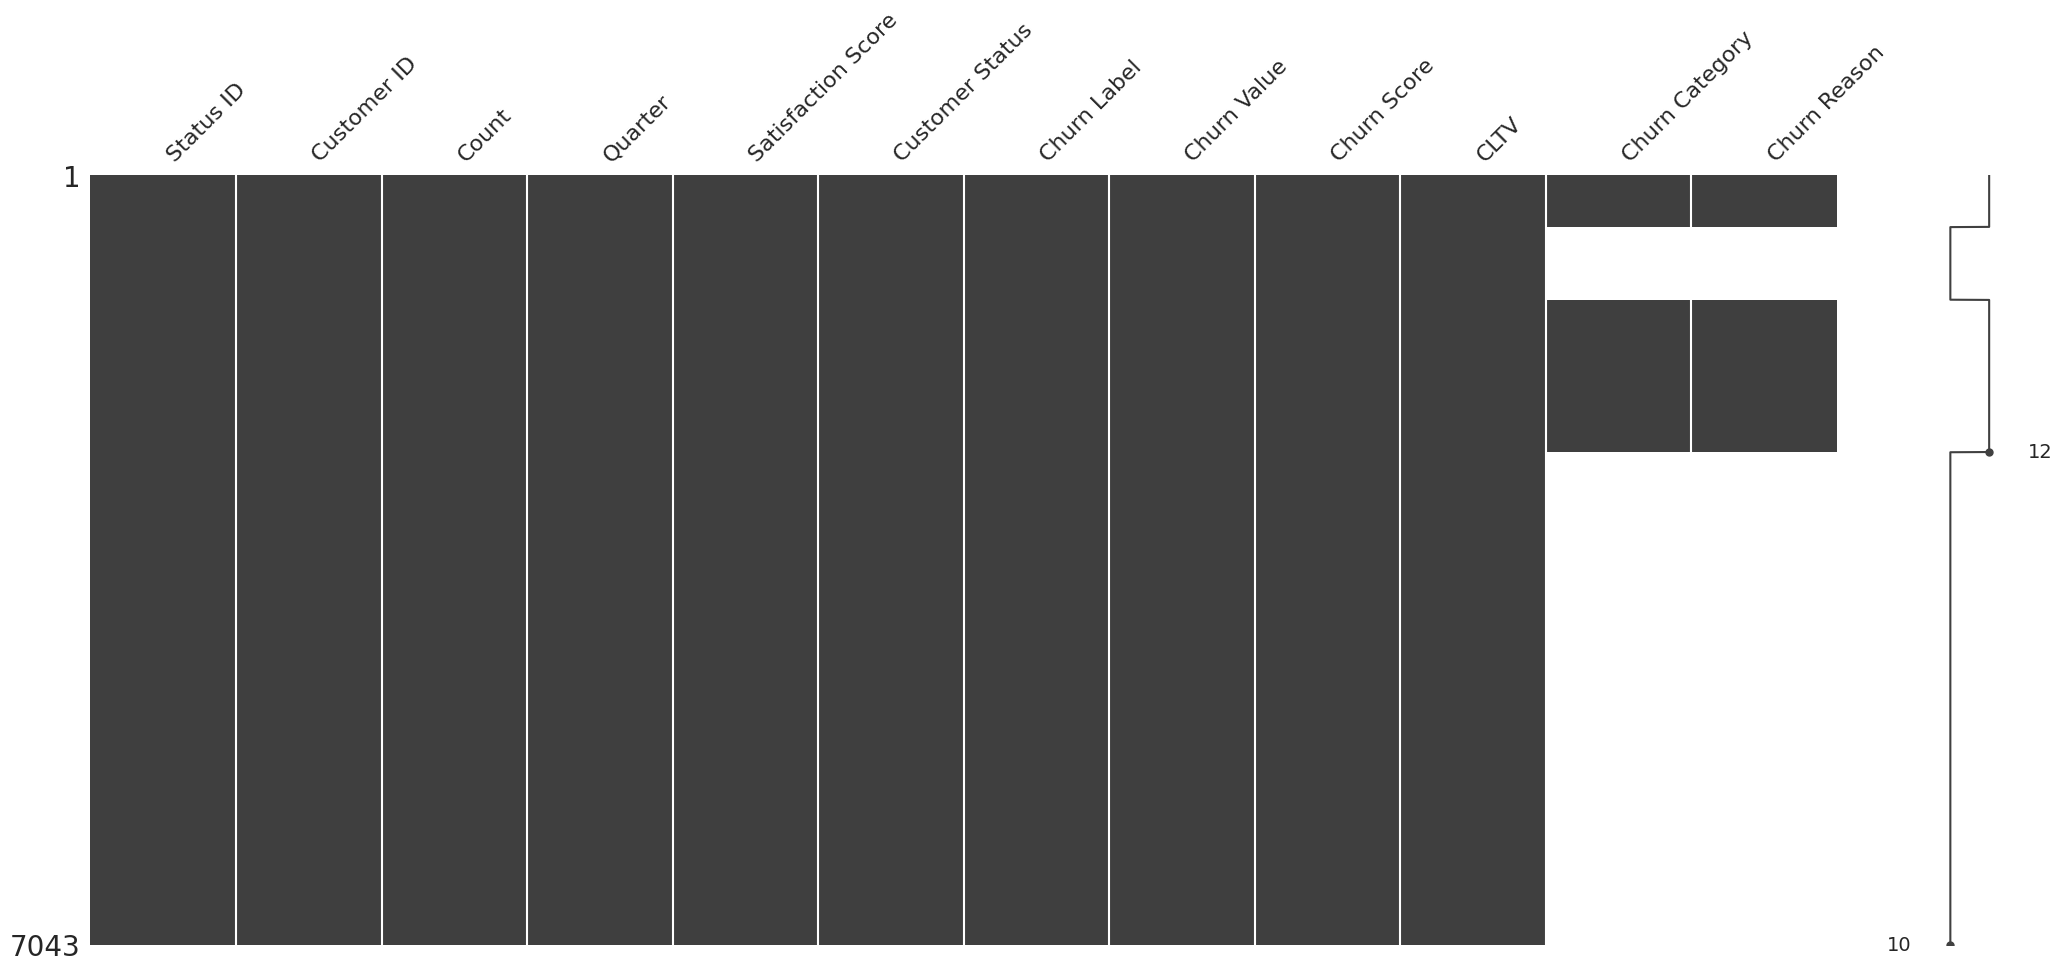

In [ ]:
# @title Missing values
# @markdown There are missing values in 2 columns of the status table that need processing

display(msno.matrix(raw_status))
display(raw_status.isna().sum())

In [ ]:
# @title Quarter
raw_status['Quarter'].value_counts()

,count
Quarter,
Q3,7043


The data is only in Q3

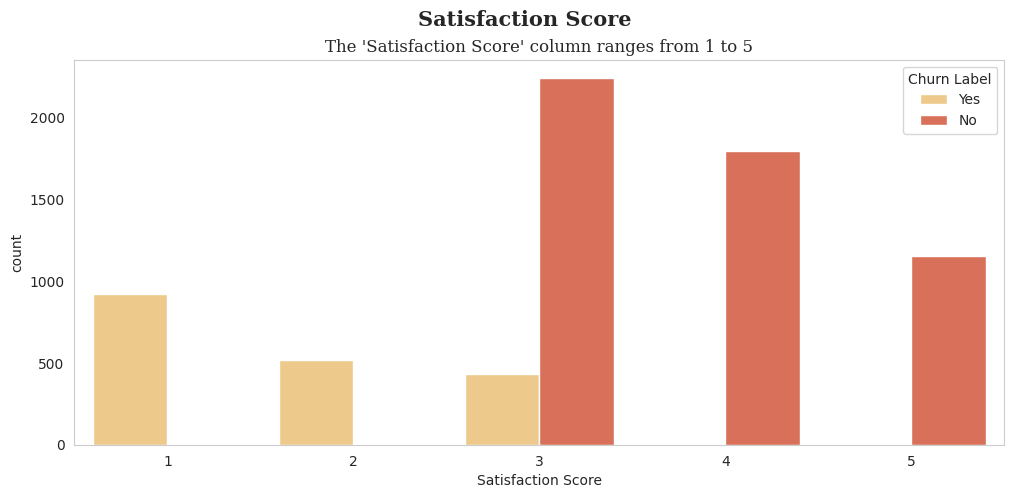

In [ ]:
# @title Satisfaction Score
plt.figure(figsize=(12, 5))
sns.countplot(data=raw_status, x='Satisfaction Score', hue='Churn Label')
plt.suptitle('Satisfaction Score', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('The \'Satisfaction Score\' column ranges from 1 to 5', fontfamily='serif', fontsize=12)
plt.show()

Those with a satisfaction score of 1 or 2 all churned, while those with 4 or 5 all stayed. Those with a satisfaction of 3 tend to stay, but some still leave.

In [ ]:
# @title Customer Status, Churn Label and Value
# @markdown *Churn Value* is the one-hot-encoded version of *Churn Label*
tmp = raw_status[['Churn Label', 'Churn Value', 'Customer Status', 'Count', 'Churn Category', 'Churn Reason']].copy()
tmp['Churn Category is Null'] = False
tmp['Churn Reason is Null'] = False
tmp.loc[tmp['Churn Category'].isna(), 'Churn Category is Null'] = True
tmp.loc[tmp['Churn Reason'].isna(), 'Churn Reason is Null'] = True
tmp.drop(columns=['Churn Category', 'Churn Reason'], inplace=True)
tmp.groupby(['Churn Label', 'Churn Value', 'Customer Status', 'Churn Category is Null', 'Churn Reason is Null']).count()

Count
Churn Label Churn Value Customer Status Churn Category is Null Churn Reason is Null       
No          0           Joined          True                   True                    454
                        Stayed          True                   True                   4720
Yes         1           Churned         False                  False                  1869

In addition, we can see that the number of users churned(1869) can also be checked with the 'Churned' value of the *Customer Status* column.  
Similarily, the number of those that did not churn(5174) is the number of users that 'Stayed' or 'Joined'. This is the same number of rows where *Churn Category* and *Churn Reason* are Null.

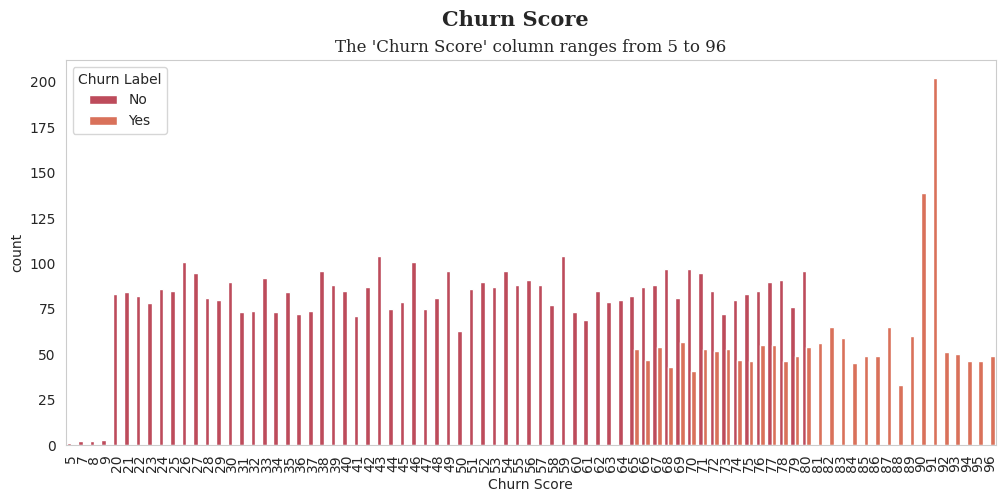

In [ ]:
# @title Churn Score
plt.figure(figsize=(12, 5))

sns.countplot(data=raw_status, x='Churn Score', hue='Churn Label')
plt.suptitle('Churn Score', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('The \'Churn Score\' column ranges from 5 to 96', fontfamily='serif', fontsize=12)
plt.xticks(rotation=90)

plt.show()

Those that churned all had churn score less than 80, while those that stayed had a score over 65.  
In other words, **users with churn score of less than 65 churned and users with more than 80 stayed**.

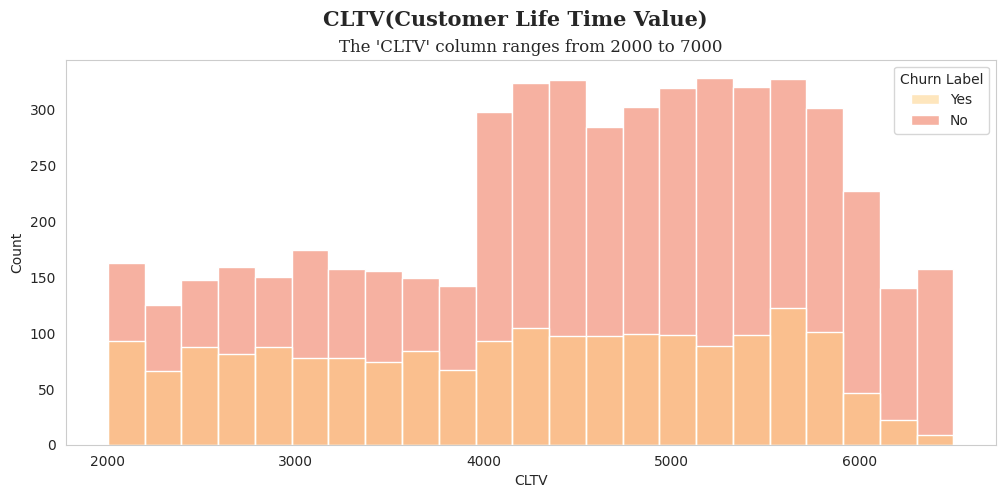

In [ ]:
# @title CLTV(Customer Life Time Value)
plt.figure(figsize=(12, 5))

sns.histplot(data=raw_status, x='CLTV', hue='Churn Label')
plt.suptitle('CLTV(Customer Life Time Value)', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('The \'CLTV\' column ranges from 2000 to 7000', fontfamily='serif', fontsize=12)

plt.show()

In [ ]:
# @title Churned Users
churned = raw_status[raw_status['Churn Label']=='Yes'][['Churn Category', 'Churn Reason', 'Count']]
churned.groupby(['Churn Category', 'Churn Reason']).count().sort_values(['Churn Category', 'Count'])

Count
Churn Category  Churn Reason                                    
Attitude        Attitude of service provider                  94
                Attitude of support person                   220
Competitor      Competitor offered higher download speeds    100
                Competitor offered more data                 117
                Competitor made better offer                 311
                Competitor had better devices                313
Dissatisfaction Poor expertise of phone support               12
                Poor expertise of online support              13
                Lack of self-service on Website               29
                Limited range of services                     37
                Service dissatisfaction                       63
                Network reliability                           72
                Product dissatisfaction                       77
Other           Deceased                                       6
                Poor expertise of online support              18
                Moved                                         46
                Don't know                                   130
Price           Lack of affordable download/upload speed      30
                Extra data charges                            39
                Long distance charges                         64
                Price too high                                78

# Data Wrangling

## Demographics

In [ ]:
demographics = raw_demographics.copy()

# One hot encoding
for col in ['Under 30', 'Senior Citizen', 'Married', 'Dependents']:
    demographics[col] = demographics[col].map({'Yes': True, 'No': False})

# Deletion
demographics.drop(columns=['Count'], inplace=True)

# Rename columns
demographics.rename(columns={'Customer ID': 'id'
                            , 'Under 30': 'under30'
                            , 'Senior Citizen': 'senior'
                            , 'Number of Dependents': 'dependents_num'}
                    , inplace='True')

for col in demographics.columns:
  demographics.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)

display(demographics.sample(2))


,id,gender,age,under30,senior,married,dependents,dependents_num
6903,2710-WYVXG,Female,36,False,False,False,False,0
3545,2782-JEEBU,Male,39,False,False,False,False,0


## Location

In [ ]:
location = raw_location.copy()

# Deletion
location.drop(columns=['Location ID', 'Count', 'Country', 'State', 'Lat Long'], inplace=True)

# Rename columns
location.rename(columns={'Customer ID': 'id'}
                , inplace='True')
for col in location.columns:
  location.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)

# Merge
demographics = pd.merge(left=demographics, right=location, how='left', on='id')

display(demographics.sample(2))

,id,gender,age,under30,senior,married,dependents,dependents_num,city,zip_code,latitude,longitude
4179,8263-QMNTJ,Male,46,False,False,True,False,0,San Francisco,94104,37.791222,-122.402241
5091,7463-IFMQU,Female,44,False,False,True,False,0,Laton,93242,36.444232,-119.718285


## Population

In [ ]:
population = raw_population.copy()

# Deletion
population.drop(columns=['ID'], inplace=True)

# Rename columns
for col in population.columns:
  population.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)

# Merge
demographics = pd.merge(left=demographics, right=population, how='left', on='zip_code')

display(demographics.sample(3))

,id,gender,age,under30,senior,married,dependents,dependents_num,city,zip_code,latitude,longitude,population
491,2504-DSHIH,Male,66,False,True,True,False,0,Thousand Oaks,91360,34.214054,-118.881090,42526
2924,1096-ADRUX,Female,34,False,False,True,True,1,Placentia,92870,33.881158,-117.854783,48170
1641,4277-PVRAN,Female,34,False,False,False,False,0,Daly City,94014,37.691561,-122.445202,47453


## Service

### Service booleans

In [ ]:
services_boolean_fields = raw_services[['Customer ID'] + services_boolean].copy()

# One-hot encode
for col in services_boolean:
  services_boolean_fields[col] = services_boolean_fields[col].map({'Yes': 1, 'No': 0})

# Rename
for col in services_boolean:
  services_boolean_fields.rename(columns={col: 'has_'+col.lower().replace(' ', '_')}, inplace=True)
services_boolean_fields.rename(columns={'Customer ID': 'id'}, inplace=True)

display(services_boolean_fields.sample(3))

# Merge
demographics = pd.merge(left=demographics, right=services_boolean_fields, how='left', on='id')

,id,has_referred_a_friend,has_phone_service,has_multiple_lines,has_internet_service,has_online_security,has_online_backup,has_device_protection_plan,has_premium_tech_support,has_streaming_tv,has_streaming_movies,has_streaming_music,has_unlimited_data,has_paperless_billing
4262,3976-HXHCE,0,1,0,0,0,0,0,0,0,0,0,0,0
2670,3645-DEYGF,0,1,0,0,0,0,0,0,0,0,0,0,0
4663,7075-BNDVQ,0,0,0,1,1,0,1,0,0,0,0,0,0


### Service categorical

In [ ]:
services_categorical_fields = raw_services[['Customer ID']+services_categorical].copy()

# Missing values
services_categorical_fields['Offer'] = services_categorical_fields['Offer'].fillna('No Offer')
services_categorical_fields['Internet Type'] = services_categorical_fields['Internet Type'].fillna('No Internet')

# Rename
for col in services_categorical:
  services_categorical_fields.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)
services_categorical_fields.rename(columns={'Customer ID': 'id'}, inplace=True)

display(services_categorical_fields.sample(3))

# Merge
demographics = pd.merge(left=demographics, right=services_categorical_fields, how='left', on='id')

,id,offer,internet_type,contract,payment_method
1986,1226-UDFZR,Offer E,Cable,Month-to-Month,Credit Card
1337,8818-XYFCQ,Offer C,Fiber Optic,Month-to-Month,Credit Card
5675,1384-RCUXW,No Offer,Fiber Optic,Month-to-Month,Credit Card


### Service numerical

In [ ]:
services_numerical_fields = raw_services[['Customer ID']+service_numerical].copy()

# Rename
for col in service_numerical:
  services_numerical_fields.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)
services_numerical_fields.rename(columns={'Customer ID': 'id'}, inplace=True)

display(services_numerical_fields.sample(3))

# Merge
demographics = pd.merge(left=demographics, right=services_numerical_fields, how='left', on='id')


,id,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
5537,4530-NDRKU,4,42,34.66,0,19.05,761.85,0.0,0,1455.72,2217.57
2809,4360-PNRQB,0,18,15.18,42,75.60,1395.05,0.0,0,273.24,1668.29
3928,1895-QTKDO,0,1,45.59,5,43.95,43.95,0.0,0,45.59,89.54


## Status

In [ ]:
status = raw_status.copy()

# Delete
status.drop(columns=['Status ID', 'Count', 'Quarter', 'Churn Label'], inplace=True)

# Missing Values
status['Churn Category'] = status['Churn Category'].fillna('Did not churn')
status['Churn Reason'] = status['Churn Reason'].fillna('Did not churn')

# Rename columns
status.rename(columns={'Customer ID': 'id'
, 'Satisfaction Score': 'CSAT'
, 'Customer Status': 'status'
, 'Churn Value': 'churned'
, 'Churn Score': 'churn_score'
, 'Churn Category': 'churn_cat'
, 'Churn Reason': 'churn_reason'}
              , inplace='True')

# Merge
demographics = pd.merge(left=demographics, right=status, how='left', on='id')

## Final Data

In [ ]:
# @title Check data
display(demographics.sample(3))
display(demographics.info())

,id,gender,age,under30,senior,married,dependents,dependents_num,city,zip_code,...,total_extra_data_charges,total_long_distance_charges,total_revenue,CSAT,status,churned,churn_score,CLTV,churn_cat,churn_reason
4272,4231-LZUYM,Female,37,False,False,True,False,0,Larkspur,94939,...,0,905.76,2792.76,5,Stayed,0,22,5613,Did not churn,Did not churn
2436,3315-TOTBP,Male,29,True,False,False,False,0,Mill Creek,96061,...,0,672.90,1803.75,1,Churned,1,74,4938,Dissatisfaction,Lack of self-service on Website
2127,8292-TYSPY,Male,55,False,False,False,False,0,Los Angeles,90048,...,30,81.70,1158.20,2,Churned,1,73,4539,Competitor,Competitor offered more data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under30                            7043 non-null   bool   
 4   senior                             7043 non-null   bool   
 5   married                            7043 non-null   bool   
 6   dependents                         7043 non-null   bool   
 7   dependents_num                     7043 non-null   int64  
 8   city                               7043 non-null   object 
 9   zip_code                           7043 non-null   int64  
 10  latitude                           7043 non-null   float64
 11  longitude                          7043 non-null   float

None

In [ ]:
# @title Save data
demographics.to_csv(os.path.join(root, 'data.csv'), index=False)